In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
import pickle
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

c:\Users\ASUS\anaconda3\envs\py310\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


**01.load data**

In [2]:
emotion_df = pd.read_csv('data/data/emotions.csv')

In [3]:
violence_df = pd.read_csv('data/data/violence.csv')

In [4]:
hate_df = pd.read_csv('data/data/hate-speach.csv')

**02.data preprocess**

remove unwanted columns

In [5]:
emotion_df.drop(columns=['Unnamed: 0'], inplace=True)
violence_df.drop(columns=['Tweet_ID'], inplace=True)
hate_df = hate_df[['tweet', 'class']]

In [6]:
emotion_df.columns, hate_df.columns, violence_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['tweet', 'class'], dtype='object'),
 Index(['tweet', 'type'], dtype='object'))

rename column names

In [7]:
hate_df.rename(columns={'tweet': 'text', 'class': 'label'}, inplace=True)
violence_df.rename(columns={'tweet': 'text', 'type': 'label'}, inplace=True)

In [8]:
emotion_df.columns, hate_df.columns, violence_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'))

In [9]:
emotion_df.isna().sum(), violence_df.isna().sum(), hate_df.isna().sum()

(text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64)

get 12000 recodes for each from emotional, violance and hate data

In [10]:
emotion_df.shape, hate_df.shape, violence_df.shape

((416809, 2), (24783, 2), (39649, 2))

In [11]:
#emotion dataset
emotion_df['label'].value_counts()

label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

In [12]:
e_df = pd.DataFrame()
for i in range(6):
  subset = emotion_df[emotion_df['label'] == i].sample(n = 2000, random_state=42)
  e_df = pd.concat([e_df, subset])

emotion_df = e_df.copy()


In [13]:
#violence dataset
violence_df['label'].value_counts()

label
sexual_violence                 32648
Physical_violence                5945
emotional_violence                651
economic_violence                 217
Harmful_Traditional_practice      188
Name: count, dtype: int64

In [14]:
sexual_violance = violence_df[violence_df['label'] == 'sexual_violence'].sample(n = 4999, random_state=42)
violence_df = violence_df[violence_df['label'] != 'sexual_violence']

In [15]:
violence_df.shape

(7001, 2)

In [16]:
violence_df = pd.concat([violence_df, sexual_violance], axis=0)

In [17]:
violence_df.shape

(12000, 2)

In [18]:
violence_df['label'].value_counts()

label
Physical_violence               5945
sexual_violence                 4999
emotional_violence               651
economic_violence                217
Harmful_Traditional_practice     188
Name: count, dtype: int64

In [19]:
#hate speech dataset
hate_df['label'].value_counts()

label
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [20]:
offensive_speech = hate_df[hate_df['label'] == 1].sample(n=6407, random_state=42)
hate_df = hate_df[hate_df['label'] != 1]

In [21]:
hate_df.shape

(5593, 2)

In [22]:
hate_df = pd.concat([hate_df, offensive_speech], axis = 0)

In [23]:
hate_df.shape

(12000, 2)

remove index

In [24]:
emotion_df.reset_index(drop=True, inplace=True)
hate_df.reset_index(drop=True, inplace=True)
violence_df.reset_index(drop=True, inplace=True)

encode violence data labels

In [25]:
label_encoder = LabelEncoder()
violence_df['label'] = label_encoder.fit_transform(violence_df['label'])

In [26]:
violence_df['label'].unique()

array([1, 3, 0, 2, 4])

remove stopwords

In [27]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [28]:
stop_words = set(stopwords.words('english'))

In [29]:
len(stop_words)

198

In [30]:
def remove_stopwords(text):
  all_words = nltk.word_tokenize(text)
  filtered_words = [word for word in all_words if word.lower() not in stop_words]
  return ' '.join(filtered_words)

In [31]:
emotion_df['text'] = emotion_df['text'].apply(remove_stopwords)
violence_df['text'] = violence_df['text'].apply(remove_stopwords)
hate_df['text'] = hate_df['text'].apply(remove_stopwords)

In [32]:
emotion_df.head()

,text,label
0,ive learned surround women lift leave feeling ...,0
1,already feel crappy upset situation doesnt help,0
2,feel like lost mourned moved past tears relati...,0
3,could write whole lot im feeling crappy dont t...,0
4,always seem feel inadequate,0


tokenize data and create tokenize sequences

In [33]:
tokernizer = Tokenizer()
tokernizer.fit_on_texts(pd.concat([emotion_df['text'], violence_df['text'], hate_df['text']]))

In [34]:
emotion_sequence = tokernizer.texts_to_sequences(emotion_df['text'])
violence_sequence = tokernizer.texts_to_sequences(violence_df['text'])
hate_sequence = tokernizer.texts_to_sequences(hate_df['text'])

In [35]:
emotion_df['text'].iloc[2]

'feel like lost mourned moved past tears relationship'

In [36]:
emotion_sequence[2:3]

[[1, 5, 321, 11845, 1208, 421, 1094, 386]]

set fixed length to sequences

In [37]:
max_length = 50
emotion_padded = pad_sequences(emotion_sequence, maxlen=max_length, padding='post')
violence_padded = pad_sequences(violence_sequence, maxlen=max_length, padding='post')
hate_padded = pad_sequences(hate_sequence, maxlen=max_length, padding='post')

In [38]:
emotion_label = np.array(emotion_df['label'])
violence_label = np.array(violence_df['label'])
hate_label = np.array(hate_df['label'])

**03.Model Definition**

In [39]:
#prapare deperate input for each dataset
emotion_input = emotion_padded
violence_input = violence_padded
hate_input = hate_padded

input layers

In [40]:
#defining mulktiple input layers for each task
emotion_input_layer = keras.layers.Input(shape=(max_length,), name='emotion_input')
violence_input_layer = keras.layers.Input(shape=(max_length,), name='violence_input')
hate_input_layer = keras.layers.Input(shape=(max_length,), name='hate_input')

embedding layers

In [41]:
#shared embedding layer
embedding_layer = keras.layers.Embedding(input_dim= len(tokernizer.word_index) + 1, output_dim=128)

In [42]:
#apply the embedding layer to each input
emotion_embedding = embedding_layer(emotion_input_layer)
violence_embedding = embedding_layer(violence_input_layer)
hate_embedding = embedding_layer(hate_input_layer)

lstm layers

In [43]:
#shared LSTM layer
lstm_layer = keras.layers.LSTM(64, return_sequences=True)

In [44]:
#apply the lstm layer to each embedding layer
emotion_lstm = lstm_layer(emotion_embedding)
violance_lstm = lstm_layer(violence_embedding)
hate_lstm = lstm_layer(hate_embedding)

pooling and dropout layers

In [45]:
#shared global average pooling layer and dropout layer
shared_pooling = keras.layers.GlobalAveragePooling1D()
shared_dropout = keras.layers.Dropout(0.5)

In [46]:
#apply the pooling and dropout layer to each embedding layer
emotion_feature = shared_dropout(shared_pooling(emotion_lstm))
violence_feature = shared_dropout(shared_pooling(violance_lstm))
hate_feature = shared_dropout(shared_pooling(hate_lstm))

output layes

In [47]:
emotion_output = keras.layers.Dense(6, activation='softmax', name='emotion_output')(emotion_feature)
violence_output = keras.layers.Dense(5, activation='softmax', name='violence_output')(violence_feature)
hate_output = keras.layers.Dense(3, activation='softmax', name='hate_output')(hate_feature)

model build and compile

In [48]:
model = keras.models.Model(
    inputs = [emotion_input_layer, violence_input_layer, hate_input_layer],
    outputs = [emotion_output, violence_output, hate_output]
)

In [49]:
model.compile(
    optimizer = 'adam',
    loss = {
        'emotion_output' : 'sparse_categorical_crossentropy',
        'violence_output' : 'sparse_categorical_crossentropy',
        'hate_output' : 'sparse_categorical_crossentropy'
    },
    metrics = {
        'emotion_output' : 'accuracy',
        'violence_output' : 'accuracy',
        'hate_output' : 'accuracy'
    }
)

In [50]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 emotion_input (InputLayer)     [(None, 50)]         0           []                               
                                                                                                  
 violence_input (InputLayer)    [(None, 50)]         0           []                               
                                                                                                  
 hate_input (InputLayer)        [(None, 50)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 50, 128)      5345152     ['emotion_input[0][0]',          
                                                                  'violence_input[0][0]',     

In [ ]:
model.fit(
    x = {
        'emotion_input' : emotion_input,
        'violence_input' : violence_input,
        'hate_input' : hate_input
    },
    y = {
        'emotion_output' : emotion_label,
        'violence_output' : violence_label,
        'hate_output' : hate_label
    },
    epochs = 10,
    batch_size = 4
)

Epoch 1/10
3000/3000 [==============================] - 78s 25ms/step - loss: 2.1515 - emotion_output_loss: 1.3840 - violence_output_loss: 0.1788 - hate_output_loss: 0.5887 - emotion_output_accuracy: 0.4099 - violence_output_accuracy: 0.9378 - hate_output_accuracy: 0.7803
Epoch 2/10
3000/3000 [==============================] - 76s 25ms/step - loss: 0.9088 - emotion_output_loss: 0.4855 - violence_output_loss: 0.0500 - hate_output_loss: 0.3733 - emotion_output_accuracy: 0.8609 - violence_output_accuracy: 0.9866 - hate_output_accuracy: 0.8689
Epoch 3/10
3000/3000 [==============================] - 56s 19ms/step - loss: 0.4840 - emotion_output_loss: 0.2274 - violence_output_loss: 0.0158 - hate_output_loss: 0.2409 - emotion_output_accuracy: 0.9344 - violence_output_accuracy: 0.9975 - hate_output_accuracy: 0.9174
Epoch 4/10
3000/3000 [==============================] - 56s 19ms/step - loss: 0.2799 - emotion_output_loss: 0.1424 - violence_output_loss: 0.0094 - hate_output_loss: 0.1281 - emotio

In [ ]:
# 1. Save the Keras model
model.save('util/model.h5')

# 2. Save the Tokenizer
with open("util/tokernizer.pkl", "wb") as f:
    pickle.dump(tokernizer, f)
    
# 3. Save the Label Encoder (for violence categories)
with open("util/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
    
# 4. Save configuration (like max_length)
config = {'max_length': 50}
with open('util/config.pkl', 'wb') as handle:
    pickle.dump(config, handle)

**04.Prediction & Evaluation**

In [65]:
prediction = model.predict({
    'emotion_input' : emotion_input,
    'violence_input' : violence_input,
    'hate_input' : hate_input
})

375/375 [==============================] - 3s 8ms/step


In [66]:
prediction

[array([[9.9998009e-01, 3.6132749e-06, 3.8485763e-07, 5.6784379e-06,
         1.0044765e-05, 1.9846949e-07],
        [9.9999464e-01, 7.0885881e-07, 1.6141647e-07, 2.9276914e-06,
         1.2202408e-06, 3.3449649e-07],
        [9.9997044e-01, 1.2563219e-06, 7.4390897e-07, 1.8529901e-05,
         7.8669582e-06, 1.0663761e-06],
        ...,
        [6.7396380e-05, 2.4385839e-04, 6.2521314e-05, 4.1539330e-05,
         3.1326301e-03, 9.9645209e-01],
        [3.5844098e-06, 4.1989560e-06, 9.6145470e-07, 2.4851201e-06,
         6.5203785e-05, 9.9992359e-01],
        [1.8816994e-05, 4.4144621e-05, 7.2406497e-06, 1.9322582e-05,
         1.4268035e-04, 9.9976784e-01]], dtype=float32),
 array([[5.6428606e-10, 1.0000000e+00, 1.8416251e-09, 4.4427737e-09,
         7.6914315e-09],
        [6.7499766e-09, 9.9999964e-01, 5.4806343e-08, 9.7822962e-08,
         2.3864959e-07],
        [8.6263077e-09, 9.9999964e-01, 4.0968743e-08, 7.8933773e-08,
         2.1410966e-07],
        ...,
        [3.2260257e-0

In [67]:
emotion_pred = np.argmax(prediction[0], axis = 1)
violence_pred = np.argmax(prediction[1], axis = 1)
hate_pred = np.argmax(prediction[2], axis = 1)

create confution matrx in heatmap

In [68]:
def plot_cm(true, pred, title, labels):
    cf = confusion_matrix(true, pred, normalize='true')
    plt.figure(figsize=(7, 6))
    sns.heatmap(cf, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Prediction')
    
emotion_labels_text = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
violence_labels_text = ['sexual_violence', 'physical_violence', 'emotional_violence', 'harmful_traditional_practices', 'economic_violence']
hate_labels_text = ['offensive_speech', 'neither', 'hate_speech']

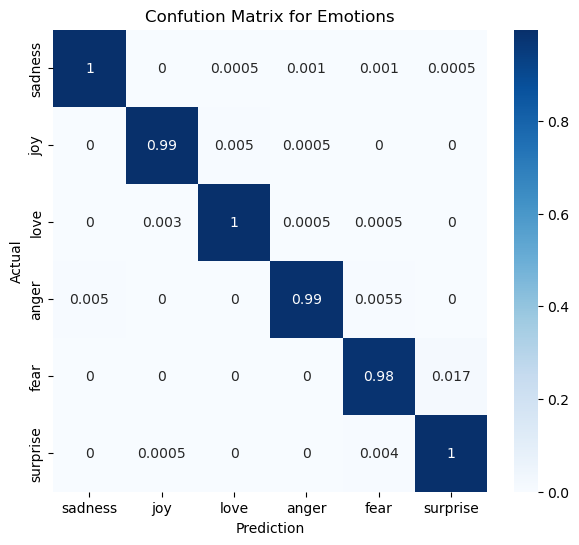

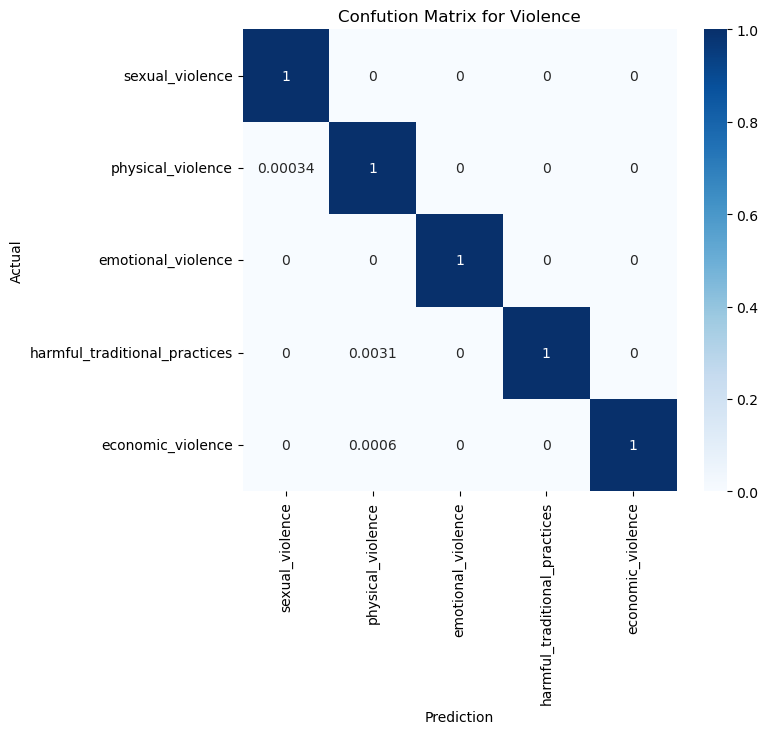

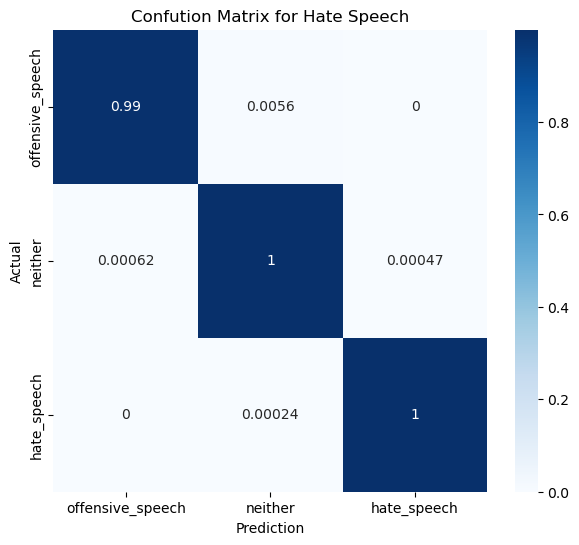

In [69]:
plot_cm(emotion_label, emotion_pred, 'Confution Matrix for Emotions', emotion_labels_text)
plot_cm(violence_label, violence_pred, 'Confution Matrix for Violence', violence_labels_text)
plot_cm(hate_label, hate_pred, 'Confution Matrix for Hate Speech', hate_labels_text)